In [9]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
GRID_SIZE = 5  #tablero
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}  


In [11]:
def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)     # posición inicial serpiente
    food = np.random.randint(0, GRID_SIZE, size=2)     # posición inicial comida
    while np.array_equal(head, food):                  # evitar posiciones iguales
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food


In [12]:
def move(head, action):
    """Desplaza la serpiente según la acción elegida"""
    if action == "up":
        head = head + np.array([-1, 0])
    elif action == "down":
        head = head + np.array([1, 0])
    elif action == "left":
        head = head + np.array([0, -1])
    elif action == "right":
        head = head + np.array([0, 1])
    return head

In [13]:
def get_reward(head, food):
    """Calcula la recompensa"""
    if np.array_equal(head, food):                     # si come la comida
        return 1
    elif np.any(head < 0) or np.any(head >= GRID_SIZE):# si choca con el borde
        return -1
    else:
        return 0

In [14]:
partidas = 1000                                        # número de simulaciones
turnos = 100                                           # turnos por partida
alpha = 0.5                                            # tasa de aprendizaje α
epsilons = [0., 0.01, 0.1]                             # diferentes niveles de exploración
recompensas_medias = np.zeros((len(epsilons), turnos)) # matriz para promediar recompensas
acciones_optimas = np.zeros((len(epsilons), turnos))   # matriz para registrar buenas decisiones


In [15]:
for ej in range(partidas):
    mejor_accion = 1                                   # acción ideal (comer)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1,6)}                 # inicializa valores Q

        head, food = init_positions()                  # posiciones iniciales

        for exp in range(turnos):
            # --- Política ε-greedy ---
            if np.random.uniform(0,1) < e:             # con probabilidad ε → exploración
                a = np.random.randint(5) + 1
            else:                                      # con probabilidad (1-ε) → explotación
                maxQ = -100
                for j in range(1, 6):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j

            # --- Ejecuta acción ---
            action_name = ACTIONS[a]
            new_head = move(head.copy(), action_name)
            recompensa = get_reward(new_head, food)
            head = new_head

            # --- Actualización incremental ---
            # Q(a) = Q(a) + α * [R - Q(a)]
            Q[a] += alpha * (recompensa - Q[a])

            # --- Guardar métricas ---
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

            if recompensa != 0:                        # si come o choca, reinicia
                head, food = init_positions()

recompensas_medias /= partidas
acciones_optimas /= partidas

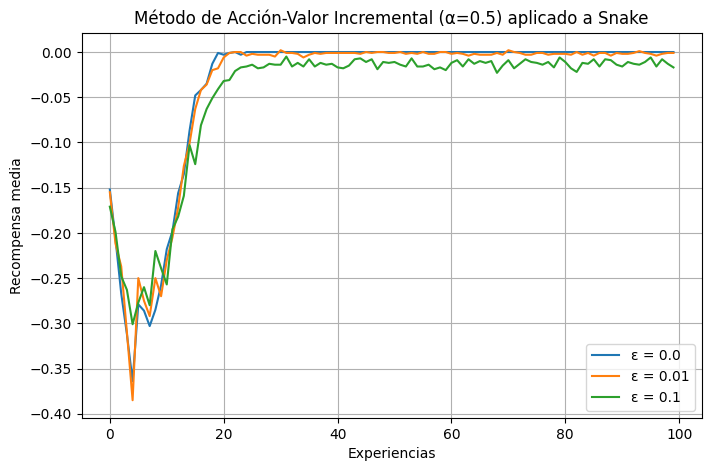

In [16]:

plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'ε = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.title('Método de Acción-Valor Incremental (α=0.5) aplicado a Snake')
plt.show()